In [ ]:
!pip install nltk scikit-learn pandas matplotlib seaborn joblib -q
print('✅ Libraries installed!')

✅ Libraries installed!


In [ ]:
from google.colab import files
import zipfile, os, io
os.makedirs('data', exist_ok=True)
print('📂 Select your archive.zip file...')
uploaded = files.upload()
for filename, content in uploaded.items():
    print(f'📦 Extracting {filename}...')

    with zipfile.ZipFile(io.BytesIO(content), 'r') as zip_ref:
        zip_ref.extractall('data/')

    print('✅ Extracted! Files found:')
    for f in os.listdir('data/'):
        print(f'   📄 {f}')

📂 Select your archive.zip file...


Saving archive (1).zip to archive (1).zip
📦 Extracting archive (1).zip...
✅ Extracted! Files found:
   📄 customer_support_tickets.csv


In [ ]:
import os
csv_files = [f for f in os.listdir('data/') if f.endswith('.csv')]
print('CSV files found:', csv_files)
if csv_files:
    if csv_files[0] != 'support_tickets.csv':
        os.rename(f'data/{csv_files[0]}', 'data/support_tickets.csv')
    print('✅ Ready as: data/support_tickets.csv')

CSV files found: ['customer_support_tickets.csv']
✅ Ready as: data/support_tickets.csv


In [ ]:
import pandas as pd
df_raw = pd.read_csv('data/support_tickets.csv')
print('Shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
print('\nFirst 3 rows:')
df_raw.head(3)

Shape: (8469, 17)

Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First 3 rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [ ]:
import os
os.rename('ticket_classifier (1).py', 'ticket_classifier.py')
print('✅ Renamed successfully!')
print('Files now:', os.listdir('.'))

✅ Renamed successfully!
Files now: ['.config', 'data', 'ticket_classifier.py', 'archive (1).zip', 'sample_data']


In [ ]:
from ticket_classifier import (
    load_kaggle_data,
    TextPreprocessor,
    TicketClassifier,
    plot_distribution,
    plot_confusion_matrices
)
print('✅ Classifier module imported successfully!')

✅ Classifier module imported successfully!


In [ ]:
df = load_kaggle_data('data/support_tickets.csv')
df.head(5)

📂 Loading Kaggle dataset...

   Raw columns found: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']
   Raw shape        : (8469, 17)

✅ Dataset ready!
   Total tickets  : 8469
   Categories     : ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
   Priority levels: ['Critical', 'Low', 'High', 'Medium']


,description,category,priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


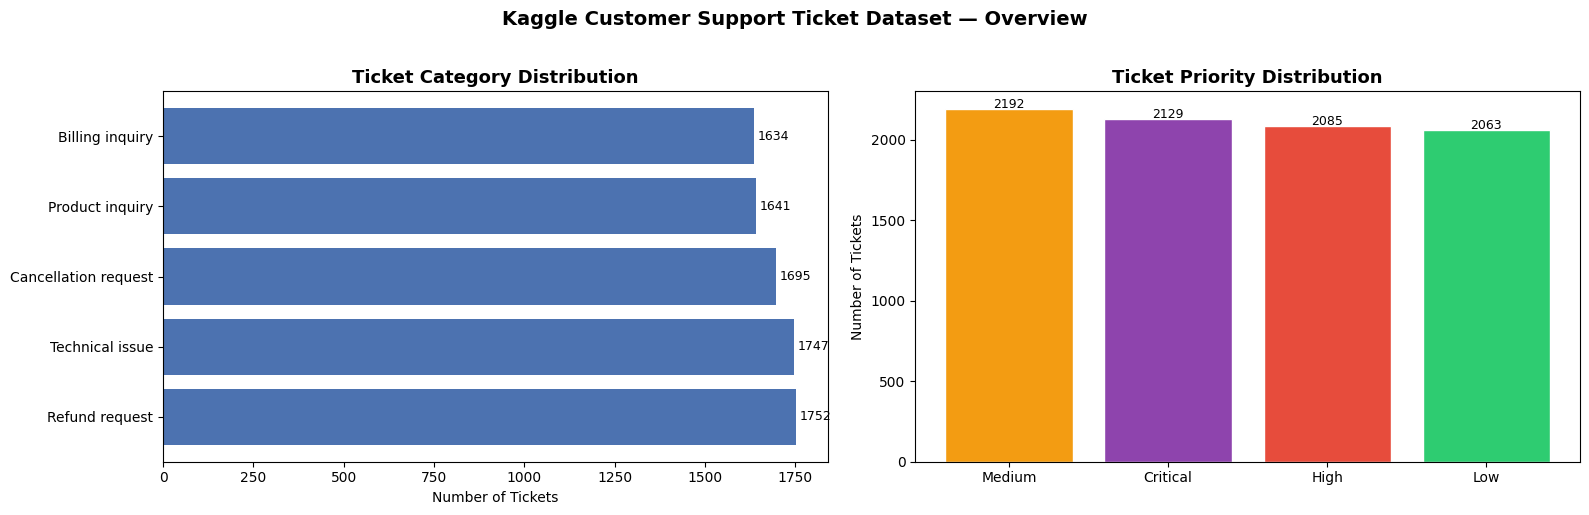

📊 Saved → outputs/data_distribution.png


In [ ]:
plot_distribution(df)

In [ ]:
preprocessor = TextPreprocessor()
sample = df['description'].iloc[0]
print('ORIGINAL TEXT:')
print(sample)
print()
print('AFTER CLEANING:')
print(preprocessor.clean(sample))

ORIGINAL TEXT:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

AFTER CLEANING:
issue product purchased please assist billing zip code appreciate requested website address please double check email address tried troubleshooting step mentioned user manual issue persists


In [ ]:
classifier = TicketClassifier()
X_test, y_cat_test, y_pri_test = classifier.train(df)


🧹 Preprocessing text...
   Train size : 6775
   Test size  : 1694

🚀 Training Category Classifier (Logistic Regression)...
🚀 Training Priority Classifier (Random Forest)...

✅ Training complete!


In [ ]:
cat_preds, pri_preds = classifier.evaluate(X_test, y_cat_test, y_pri_test)


  📊 EVALUATION RESULTS

📌 CATEGORY CLASSIFICATION REPORT
-----------------------------------------------------------------
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.20      0.20       327
Cancellation request       0.21      0.20      0.21       339
     Product inquiry       0.22      0.21      0.22       328
      Refund request       0.20      0.22      0.21       351
     Technical issue       0.22      0.24      0.23       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694


📌 PRIORITY CLASSIFICATION REPORT
-----------------------------------------------------------------
              precision    recall  f1-score   support

    Critical       0.28      0.28      0.28       441
        High       0.25      0.22      0.24       424
         Low       0.23      0.27      0.24       37

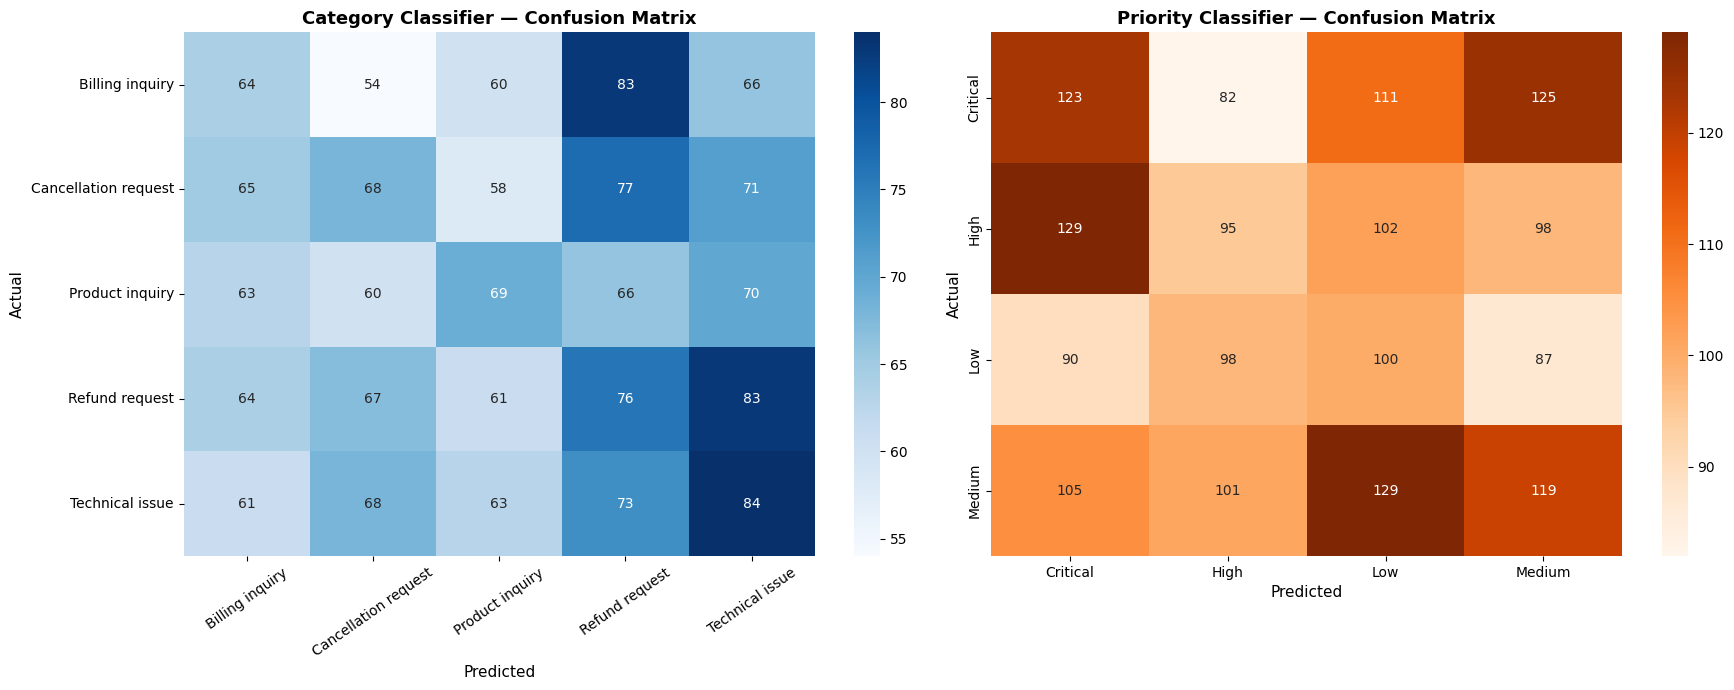

📊 Saved → outputs/confusion_matrices.png


In [ ]:
plot_confusion_matrices(y_cat_test, cat_preds, y_pri_test, pri_preds)

In [ ]:
classifier.save()


💾 Models saved → 'models/' folder


In [ ]:
my_ticket = "I have been charged twice for my subscription this month. Please refund immediately."
result = classifier.predict(my_ticket)
def emoji_bar(score, total=20):
    filled = int((score / 100) * total)
    return '🟩' * filled + '⬜' * (total - filled)
print('=' * 55)
print('📝 YOUR TICKET:')
print(result['input_text'])
print()
print(f"  ➤ Predicted Category : {result['predicted_category']}")
print(f"  ➤ Predicted Priority  : {result['predicted_priority']}")
print()
print('  📊 Category Confidence:')
for cat, score in sorted(result['category_confidence'].items(), key=lambda x: -x[1]):
    print(f"    {cat:<25} {score}%")
    print(f"    {emoji_bar(score)}")
    print()
print('  📊 Priority Confidence:')
for pri, score in sorted(result['priority_confidence'].items(), key=lambda x: -x[1]):
    print(f"    {pri:<10} {score}%")
    print(f"    {emoji_bar(score)}")
    print()
print('=' * 55)

📝 YOUR TICKET:
I have been charged twice for my subscription this month. Please refund immediately.

  ➤ Predicted Category : Product inquiry
  ➤ Predicted Priority  : Medium

  📊 Category Confidence:
    Product inquiry           34.4%
    🟩🟩🟩🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Cancellation request      19.9%
    🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Technical issue           16.3%
    🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Refund request            14.9%
    🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Billing inquiry           14.5%
    🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

  📊 Priority Confidence:
    Medium     34.5%
    🟩🟩🟩🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Critical   31.0%
    🟩🟩🟩🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    High       18.0%
    🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜

    Low        16.5%
    🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜



In [ ]:
from google.colab import files
files.download('outputs/data_distribution.png')
files.download('outputs/confusion_matrices.png')
print('✅ Charts downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Charts downloaded!
